<div style="display:flex; align-items:center; gap:18px; text-align:left">
  <img src="https://sebastiancontz.github.io/ust-diplomado-ia-curso-ml/assets/logo_ust.png" width="100">
  <div>
    <p>Diplomado en Inteligencia Artificial para los Negocios</p>
    <p>Facultad de Ingeniería y Negocios</p>
    <p>Módulo 2: Fundamentos de Machine Learning y herramientas Low Code</p>
    <p>Semana 02: Conocer y preparar los datos</p>
  </div>
</div>


# 02 · Conocer y preparar los datos

Antes de entrenar cualquier modelo hay que **conocer y preparar los datos** — la fase que más decide el
resultado de un proyecto (suele consumir el **70–80 %** del tiempo). En este notebook recorremos esa fase
sobre un caso real: **precios de venta de casas de la Región Metropolitana**.

**Al terminar sabrás:**

- distinguir los **tipos de variable** y reconocer el *target* y las *features*;
- **explorar** un dataset (reporte automático, distribuciones, relaciones);
- detectar y entender **valores faltantes** y **outliers**;
- dejar los datos **listos para modelar** con PyCaret, en pocas líneas.

> El **modelado** en sí (entrenar y evaluar modelos) es el tema de las próximas clases. Hoy preparamos el terreno.

## Preparación del entorno

Instalamos las librerías (PyCaret va **pineado** para reproducibilidad). Si Colab pide reiniciar el
entorno tras instalar, ve a **Entorno de ejecución → Reiniciar sesión** y vuelve a correr desde aquí.

In [1]:
%%capture
!pip install -q pycaret==4.0.0a8 fg-data-profiling missingno ipywidgets plotly "setuptools<81"


<!-- migracion-modular: api-nuevas -->
## APIs de pandas que se incorporan

- `read_csv` carga el archivo CSV; `head` muestra una muestra breve de la tabla.
- `isna` identifica valores faltantes y `fillna` los completa con una regla explícita.
- `assign` crea columnas derivadas sin cambiar la tabla original; `astype` fija el tipo de una columna.


In [2]:
%matplotlib inline
import os
import pandas as pd
import plotly.express as px

# En Colab los datos se leen del repo público; en local, desde ../datasets/
REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-fundamentos-machine-learning-colab/main/ediciones/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

df = pd.read_csv(BASE + 'precios_casas_rm.csv')
print('Filas y columnas:', df.shape)
df.head()

# evita que el pipeline de PyCaret se imprima como HTML enorme
from sklearn import set_config
set_config(display='text')


Filas y columnas: (2377, 15)


## ¿Dónde estamos en el proyecto?

En un proyecto de datos (marco **CRISP-DM**), hoy trabajamos las fases que más pesan: **comprender** y
**preparar** los datos. El modelado viene después.

<p align="center"></p>

## 1. Los datos: una tabla

Trabajamos con datos **tabulares**: una tabla donde cada **fila** es una observación (aquí, una **casa**)
y cada **columna** es una **variable**. Distinguimos dos roles:

- **Variable objetivo (*target*)**: lo que queremos predecir → en este caso **`precio_uf`**.
- **Variables predictoras (*features*)**: la información de entrada (superficie, comuna, dormitorios…).

El **tipo del target** define la tarea: como `precio_uf` es un **número**, es un problema de **regresión**.

<p align="center"></p>

In [3]:
# columnas disponibles y un vistazo general
print('Columnas:', list(df.columns))
df.describe(include='all').T

Columnas: ['latitud', 'longitud', 'area_construida', 'area_total', 'dormitorios', 'banos', 'estacionamiento', 'bodega', 'piscina', 'quincho', 'precio_uf', 'comuna', 'distancia_a_estacion_cercana', 'estacion_cercana', 'metro']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
latitud,2377.0,NaN,NaN,NaN,-33.479243,0.09931,-33.645794,-33.553701,-33.492551,-33.420685,-33.182001
longitud,2377.0,NaN,NaN,NaN,-70.651923,0.094013,-70.906166,-70.727645,-70.639116,-70.568352,-70.495797
area_construida,2235.0,NaN,NaN,NaN,100.619298,37.566123,34.0,74.0,95.0,123.0,374.0
area_total,2377.0,NaN,NaN,NaN,199.167299,99.904255,52.0,128.0,178.0,250.0,651.57
dormitorios,2377.0,NaN,NaN,NaN,3.341186,0.840449,1.0,3.0,3.0,4.0,5.0
banos,2377.0,NaN,NaN,NaN,2.133361,0.925855,1.0,1.0,2.0,3.0,5.0
estacionamiento,2259,2,Si,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bodega,2377,2,Si,1925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
piscina,2377,2,Si,1934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quincho,2377,2,Si,1929,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Tipos de variable

Reconocer el **tipo** de cada variable es el primer paso: decide cómo se trata, cómo se imputa si falta y
qué operaciones tienen sentido.

- **Numéricas** (cantidades): **discretas** (conteos: nº de dormitorios) o **continuas** (mediciones: superficie, precio).
- **Categóricas** (etiquetas): **nominales** (sin orden: comuna) u **ordinales** (con orden: bajo < medio < alto).

<p align="center"></p>

In [4]:
# pandas infiere un tipo por columna: object = texto/categórica, int/float = numérica
df.dtypes

latitud                         float64
longitud                        float64
area_construida                 float64
area_total                      float64
dormitorios                       int64
banos                             int64
estacionamiento                  object
bodega                           object
piscina                          object
quincho                          object
precio_uf                       float64
comuna                           object
distancia_a_estacion_cercana    float64
estacion_cercana                 object
metro                            object
dtype: object

## 3. Explorar antes de modelar (EDA)

El **análisis exploratorio** (*EDA*) es mirar los datos **antes** de modelar: entenderlos, detectar
problemas de calidad y ver relaciones. ¿Por qué no basta con las estadísticas? El **cuarteto de Anscombe**
lo deja claro: cuatro conjuntos con **las mismas** estadísticas (media, varianza, correlación) pero formas
**muy distintas** al graficarlos.

<p align="center">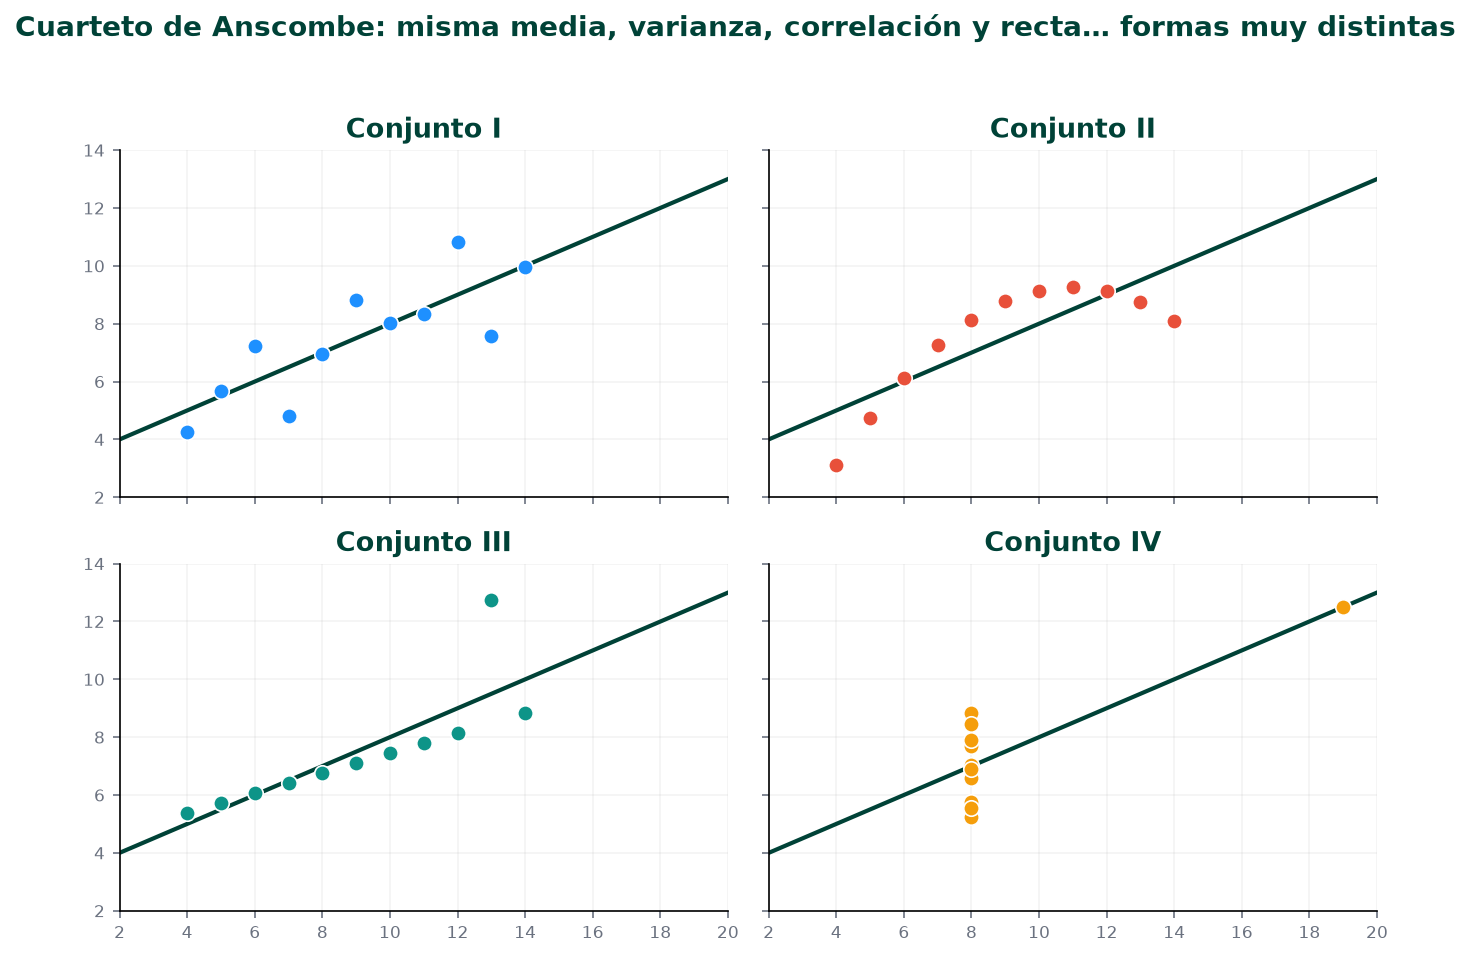</p>

Por eso siempre hay que **mirar** los datos. Una librería de *profiling* genera, en una línea, un
**reporte automático** completo (tipos, faltantes, distribuciones, correlaciones, alertas).

In [ ]:
from data_profiling import ProfileReport

profile = ProfileReport(df, title='Casas RM — perfil de datos')
profile.to_notebook_iframe()

Revisa en el reporte: **¿cuántas filas y columnas?**, **¿qué variables tienen faltantes y en qué %?**,
**¿hay duplicados?**, **¿qué forma tienen las distribuciones?** El reporte **señala dónde mirar**;
interpretar y decidir sigue siendo tuyo.

## 4. Mirar relaciones (gráficos interactivos)

Con **plotly** podemos explorar de forma interactiva (pasa el mouse por encima para ver detalles).
Primero, **cómo se distribuye** el precio:

In [6]:
px.histogram(df, x='precio_uf', nbins=50, title='Distribución del precio (UF)')

Ahora una **relación**: ¿se relaciona la superficie construida con el precio? Coloreamos por comuna.

In [7]:
df_plot = df.assign(
    dormitorios_cat=df['dormitorios'].round().astype('Int64').astype('string').fillna('sin dato')
)

px.scatter(
    df_plot,
    x='area_construida',
    y='precio_uf',
    color='dormitorios_cat',
    hover_data=['comuna', 'banos'],
    title='Precio vs. superficie construida (color = nº de dormitorios)',
    labels={
        'area_construida': 'área construida (m²)',
        'precio_uf': 'precio (UF)',
        'dormitorios_cat': 'dormitorios'
    },
)


Se ve una tendencia: a mayor superficie, mayor precio (con bastante dispersión). Explorar así ayuda a
**formar hipótesis** antes de modelar.

## 5. Valores faltantes (nulos)

En datos reales casi siempre **faltan valores** (las herramientas los llaman **nulos**: `NaN`). Ocurren
por errores de registro o porque el dato no existe. La mayoría de los modelos **no** pueden trabajar con
celdas vacías, así que hay que resolverlas.

In [8]:
# ¿cuántos faltantes hay por columna?
df.isna().sum()

latitud                           0
longitud                          0
area_construida                 142
area_total                        0
dormitorios                       0
banos                             0
estacionamiento                 118
bodega                            0
piscina                           0
quincho                           0
precio_uf                         0
comuna                            0
distancia_a_estacion_cercana      0
estacion_cercana                  0
metro                             0
dtype: int64

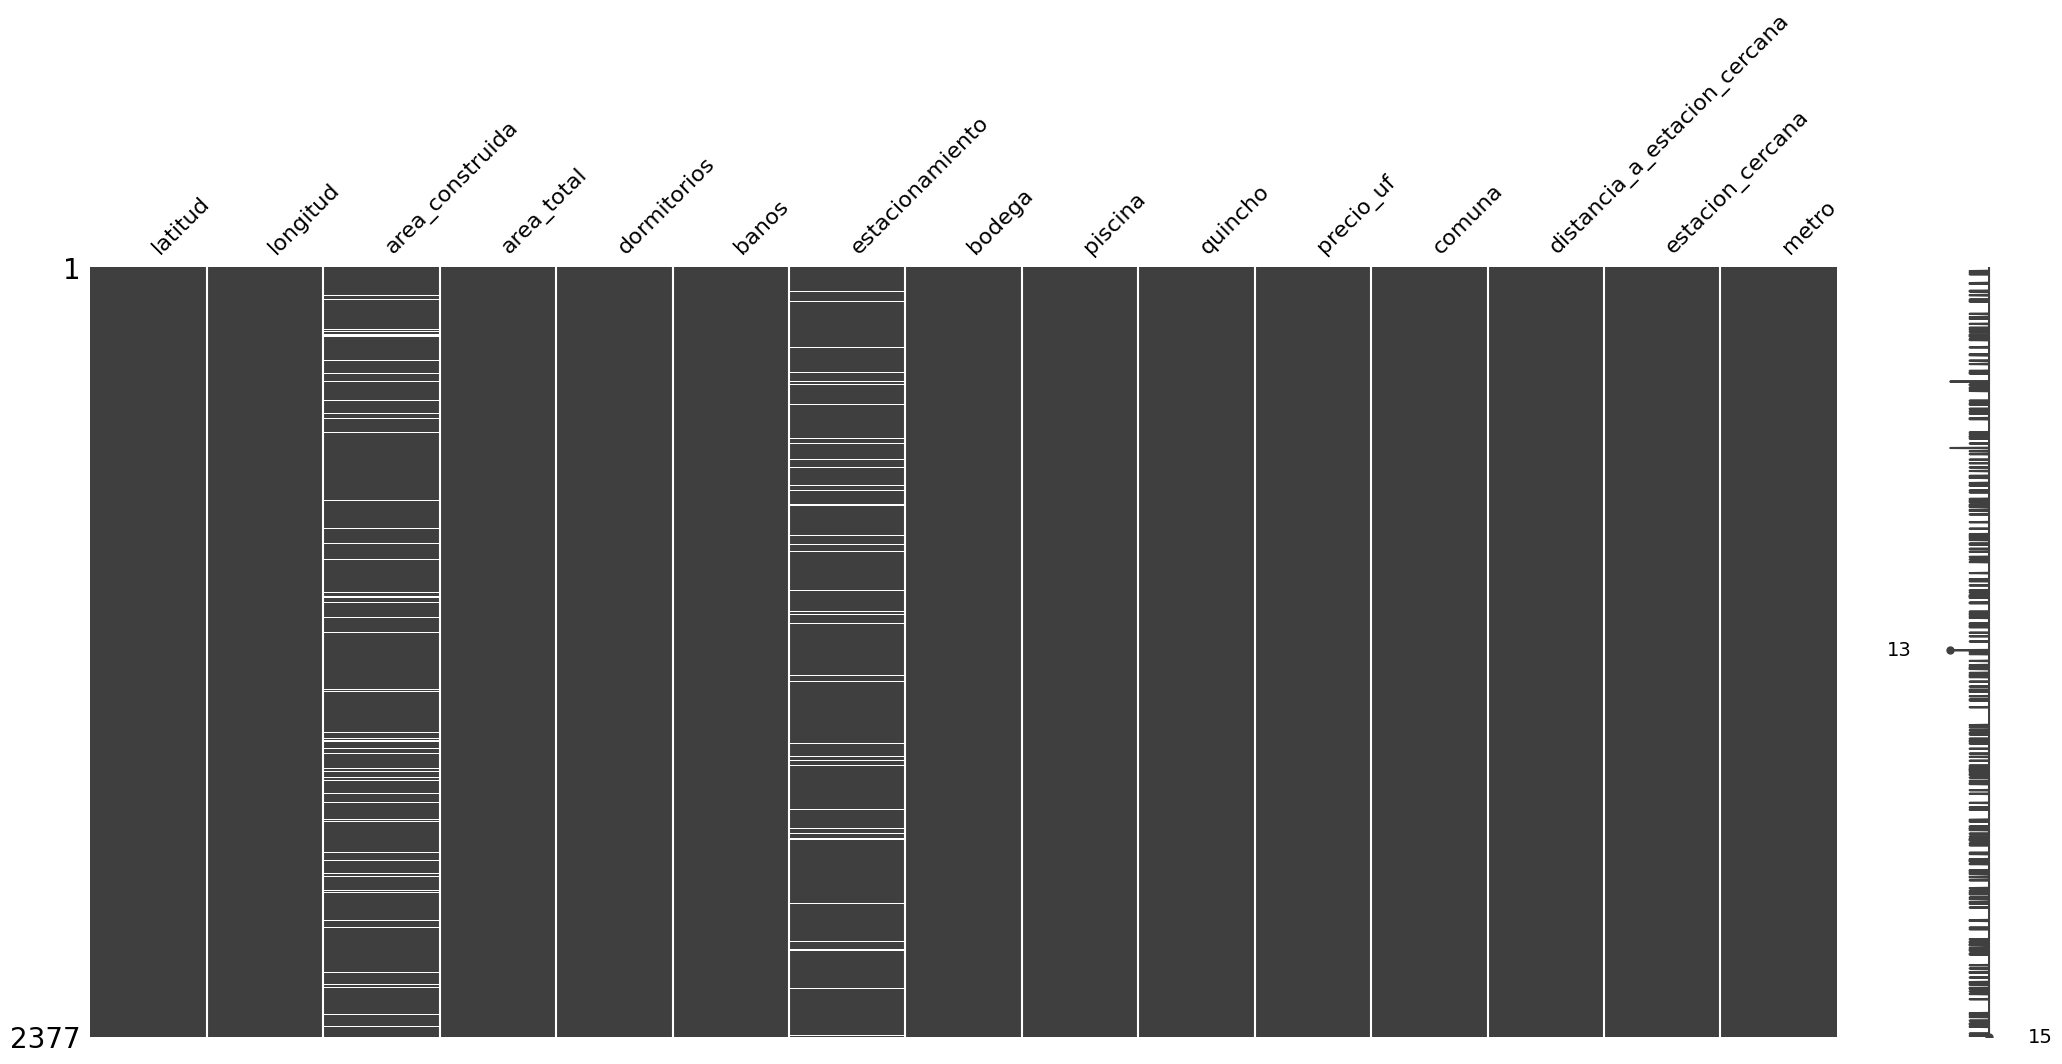

In [9]:
# missingno: ver el PATRÓN de faltantes de un vistazo (franjas blancas = datos ausentes)
import missingno as msno
msno.matrix(df);

**Imputar** es rellenar esos vacíos con una "conjetura educada". Aquí se ve por qué importa el **tipo**:

- `area_construida` es **numérica** → se imputa con la **mediana** (resiste mejor los extremos).
- `estacionamiento` es **categórica** (Sí/No) → se imputa con la **moda** (el valor más frecuente).

PyCaret hace esta imputación **automáticamente** al preparar los datos.

## 6. Valores atípicos (*outliers*)

Un **outlier** es un valor muy alejado del resto. **Ejemplo:** en un barrio las casas valen ~4.000 UF en
promedio; si sumamos un **sector muy exclusivo** (~8.000 UF o más), esas casas aparecen como outliers.
**No son un error**: son reales, de otro segmento → conviene **investigar**, no borrar a ciegas.

El **boxplot** (diagrama de caja) los detecta de un vistazo:

<p align="center">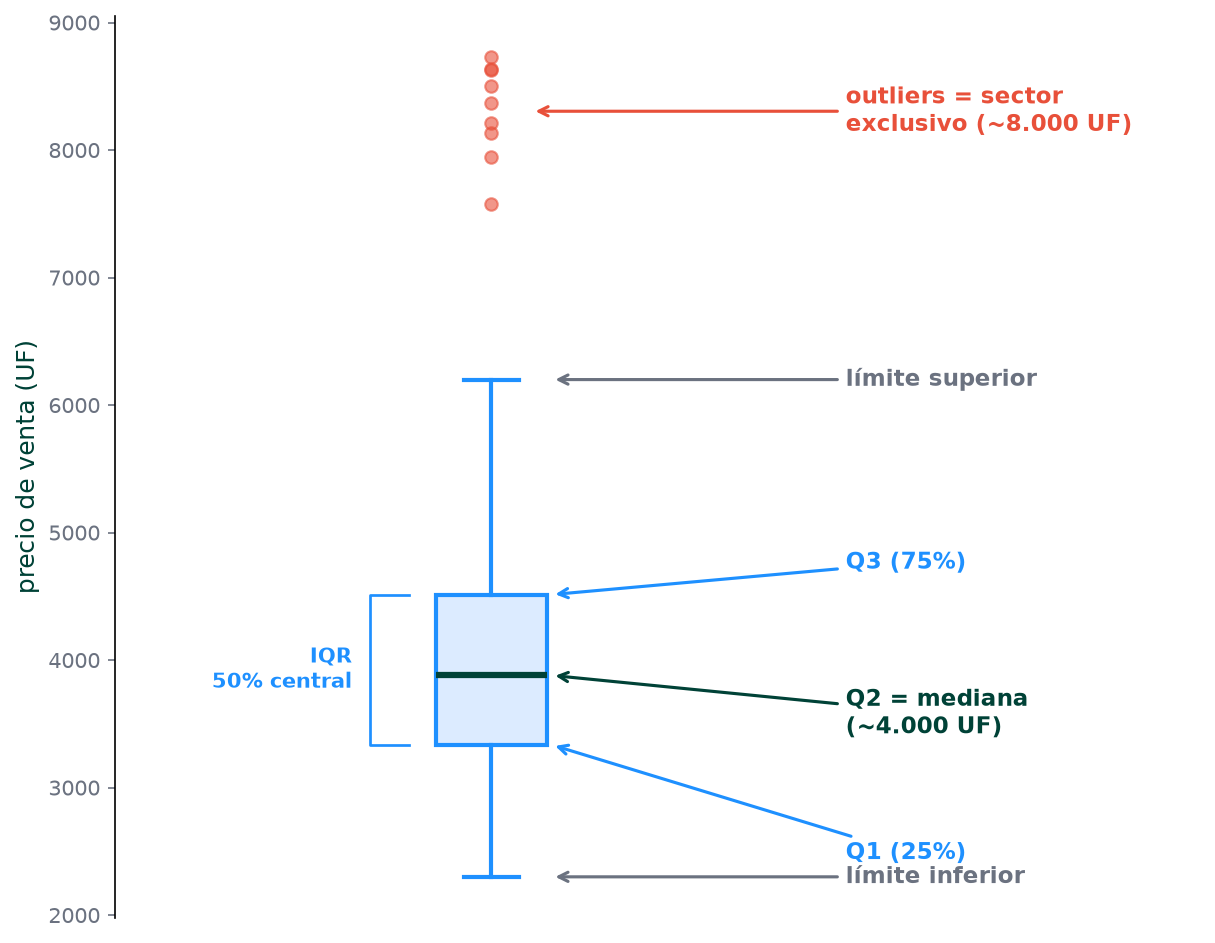</p>

**La IA como copiloto:** no necesitas memorizar el código de un gráfico. Puedes pedírselo a una IA:

> *"Tengo un DataFrame `df` con la columna numérica `precio_uf`. Hazme un boxplot interactivo de esa
> columna con plotly y explícame cómo leerlo."*

Lo importante es **qué pedir** y **cómo interpretarlo**. Esto es lo que devolvería:

In [10]:
px.box(df, x='precio_uf', points='outliers', title='Boxplot del precio (UF)')

Los puntos a la derecha son **outliers**: casas mucho más caras que el grueso. Pasa el mouse para ver
los cuartiles. ¿Errores o casas de lujo reales? Aquí, reales → se investigan, no se borran.

## 7. Dejar los datos listos para modelar

Un modelo necesita la tabla en cierto estado. El paso **más importante** es **separar entrenamiento y
prueba**: apartamos una parte que el modelo **no ve** al entrenar, para evaluarlo después con **casos
nuevos**. Así medimos si **generaliza** (y no solo si **memoriza**).

<p align="center"></p>

Si el modelo memoriza el entrenamiento, sufre **sobreajuste** (*overfitting*) y falla con datos nuevos.
El buen modelo es el que **generaliza** (el del medio):

<p align="center">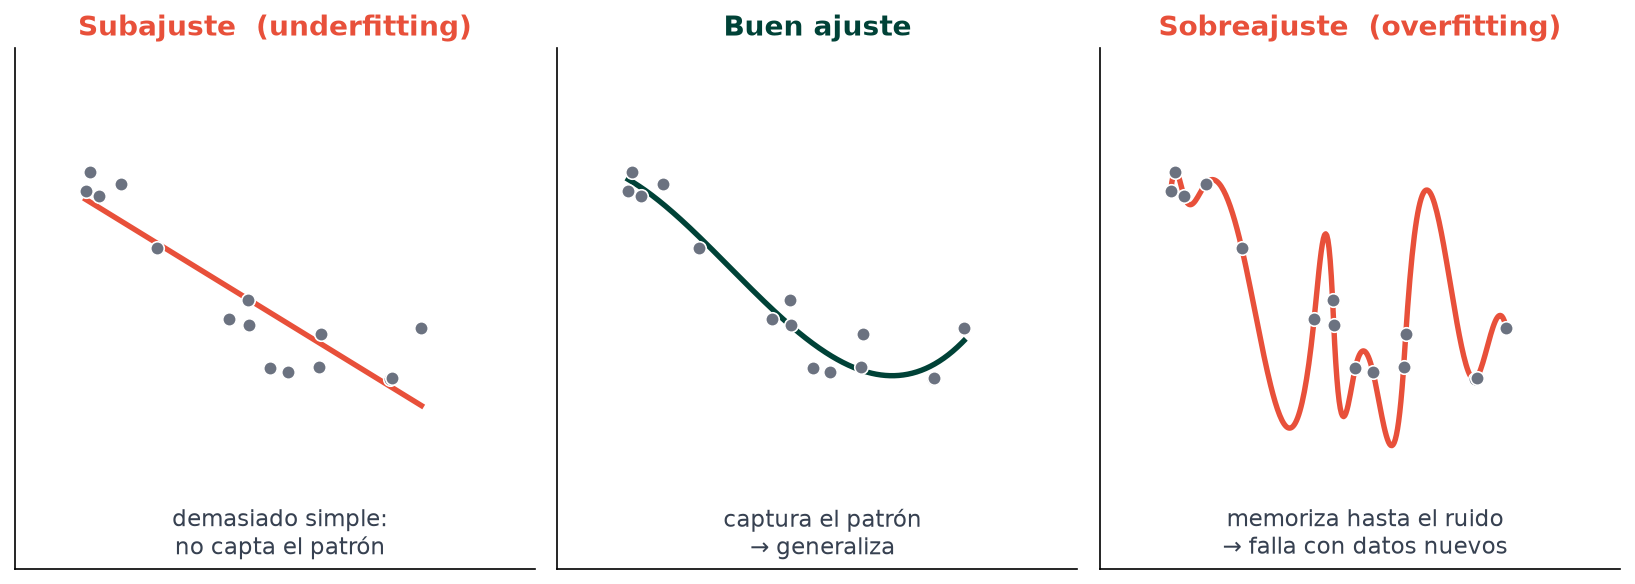</p>

Además, PyCaret **codifica** las categóricas (las traduce a números, porque el modelo solo hace
cuentas), **imputa** los faltantes y opcionalmente **escala**. Todo eso ocurre al crear el experimento y
llamar a `.fit()`:

<p align="center"></p>

In [11]:
from pycaret.tasks import RegressionExperiment

exp = RegressionExperiment(target='precio_uf', session_id=42).fit(df)

# ¿cuántas filas quedaron para entrenar y cuántas para el "examen final"?
print('Entrenamiento:', exp.X_train.shape, '| Prueba:', exp.X_test.shape)

Entrenamiento: (1663, 14) | Prueba: (714, 14)


## 8. Una pizca de ingeniería de variables

La **ingeniería de variables** es crear o transformar columnas —con conocimiento del negocio— para revelar
patrones (de fecha de nacimiento → edad; de superficie total y construida → % construido).

> **Cuidado — fuga de datos:** nunca uses la variable que quieres **predecir** (el precio) para construir
> otras. No tendrías el precio *antes* de predecirlo. (Lo vemos a fondo en la Clase 6.)

## El destino: comparar modelos

Con los datos **listos**, comparar muchos modelos es **casi una línea**. Es solo un **vistazo**: leer esta
tabla de métricas es el tema de la Clase 3.

In [12]:
mejor = exp.compare_models()   # entrena y ordena una galería de modelos
mejor.best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070787 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1281
[LightGBM] [Info] Number of data points in the train set: 1496, number of used features: 14
[LightGBM] [Info] Start training from score 4603.155734
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1283
[LightGBM] [Info] Number of data points in the train set: 1496, number of used features: 14
[LightGBM] [Info] Start training from score 4645.262092


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1276
[LightGBM] [Info] Number of data points in the train set: 1496, number of used features: 14
[LightGBM] [Info] Start training from score 4607.214800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1278
[LightGBM] [Info] Number of data points in the train set: 1497, number of used features: 14
[LightGBM] [Info] Start training from score 4565.587356
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1285
[LightGBM] [Info] Number of data points in the train set: 1497, number of used features: 14
[LightGBM] [Info] Start 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1285
[LightGBM] [Info] Number of data points in the train set: 1497, number of used features: 14
[LightGBM] [Info] Start training from score 4581.447066
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1286
[LightGBM] [Info] Number of data points in the train set: 1497, number of used features: 14
[LightGBM] [Info] Start training from score 4638.433739
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1282
[LightGBM] [Info] Number of data points in the train

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1286
[LightGBM] [Info] Number of data points in the train set: 1663, number of used features: 14
[LightGBM] [Info] Start training from score 4601.473272


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  SimpleImputer(),
                                                  ['latitud', 'longitud',
                                                   'area_construida',
                                                   'area_total', 'dormitorios',
                                                   'banos',
                                                   'distancia_a_estacion_cercana']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
    

---
### Cierre

El trabajo duro fue **conocer y preparar los datos**: tipos, calidad, faltantes y outliers. Con eso
resuelto, modelar "viene casi gratis" — y es justo el tema de las próximas clases.

**Para practicar:** elige una variable y proponla como *feature* nueva (sin usar el precio). ¿Por qué no
podrías usar el precio para construirla?

<!-- migracion-modular: atribucion-datos -->
## Atribución de datos

**Creador:** Sebastián Contreras, extracción y preparación para uso docente.
**Fuente:** avisos inmobiliarios de [Enlace Inmobiliario](https://www.enlaceinmobiliario.cl/) y [GoPlaceIt](https://www.goplaceit.com/), obtenidos mediante *web scraping*.
**Licencia:** No declarada para esta compilación; fuentes originales: [Enlace Inmobiliario](https://www.enlaceinmobiliario.cl/) y [GoPlaceIt](https://www.goplaceit.com/).
**Modificación:** columnas estandarizadas, codificación UTF-8 y faltantes didácticos; no se incluyen identificadores personales.
